In [1]:
"""
VibeSignal AI — Exploratory Data Analysis
Notebook 01: Understanding Indian D2C creator performance patterns

"""

import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["font.size"]      = 11

# absolute path — works regardless of where notebook is run from
DATA_DIR   = r"C:\Users\vinni\vibesignal-ai\data"
CHARTS_DIR = r"C:\Users\vinni\vibesignal-ai\notebooks"

os.makedirs(CHARTS_DIR, exist_ok=True)

creators          = pd.read_csv(os.path.join(DATA_DIR, "creators.csv"))
campaigns         = pd.read_csv(os.path.join(DATA_DIR, "campaigns.csv"))
campaign_creators = pd.read_csv(os.path.join(DATA_DIR, "campaign_creators.csv"))
posts             = pd.read_csv(os.path.join(DATA_DIR, "posts.csv"))
conversions       = pd.read_csv(os.path.join(DATA_DIR, "conversions.csv"))
demographics      = pd.read_csv(os.path.join(DATA_DIR, "audience_demographics.csv"))

print("All datasets loaded.")
print()
print(f"creators:          {creators.shape}")
print(f"campaigns:         {campaigns.shape}")
print(f"campaign_creators: {campaign_creators.shape}")
print(f"posts:             {posts.shape}")
print(f"conversions:       {conversions.shape}")
print(f"demographics:      {demographics.shape}")

All datasets loaded.

creators:          (200, 19)
campaigns:         (70, 13)
campaign_creators: (361, 9)
posts:             (1113, 14)
conversions:       (1972, 12)
demographics:      (3400, 6)


In [2]:
# ── Step 1: shape and null check ─────────────────────────────

print("=" * 55)
print("CREATORS — column types and nulls")
print("=" * 55)
creators.info()
print()

print("=" * 55)
print("NULL COUNTS across key tables")
print("=" * 55)

for name, df in [
    ("creators",    creators),
    ("posts",       posts),
    ("conversions", conversions),
]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(f"\n{name}:")
    if len(nulls) == 0:
        print("  no nulls")
    else:
        print(nulls)

print()

# audience_authenticity_score should now be populated — verify
auth_nulls = creators["audience_authenticity_score"].isnull().sum()
print(f"audience_authenticity_score nulls: {auth_nulls}  (should be 0)")

print()
print("=" * 55)
print("CREATORS — sample rows")
print("=" * 55)
creators[[
    "name", "tier", "platform", "niche",
    "follower_count", "avg_engagement_rate",
    "estimated_cost_inr", "authenticity_risk_level"
]].head(5)

CREATORS — column types and nulls
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   creator_id                   200 non-null    int64  
 1   name                         200 non-null    object 
 2   handle                       200 non-null    object 
 3   platform                     200 non-null    object 
 4   niche                        200 non-null    object 
 5   tier                         200 non-null    object 
 6   follower_count               200 non-null    int64  
 7   avg_engagement_rate          200 non-null    float64
 8   estimated_cost_inr           200 non-null    int64  
 9   country                      200 non-null    object 
 10  primary_language             200 non-null    object 
 11  city_tier                    200 non-null    object 
 12  follower_growth_spike        200 non-null   

,name,tier,platform,niche,follower_count,avg_engagement_rate,estimated_cost_inr,authenticity_risk_level
0,Aryan Maharaj,micro,instagram,gaming,22224,5.78,15745,low
1,Liam Chaudry,nano,twitter,tech,7396,7.06,7923,medium
2,Pahal Balay,nano,instagram,tech,5861,6.87,1979,medium
3,Tejas Kaul,nano,instagram,fashion,3579,6.23,5660,low
4,Rushil Saini,micro,youtube,travel,42271,4.74,9302,high


TIER STATS — engagement decreases as tier grows
       count  avg_followers  avg_engagement_rate  avg_cost_inr
tier                                                          
nano     103        5399.52                 7.89       4720.98
micro     56       51777.77                 4.36      22832.68
macro     31      487193.16                 2.27     117607.87
mega      10     3631723.90                 1.12     680608.40



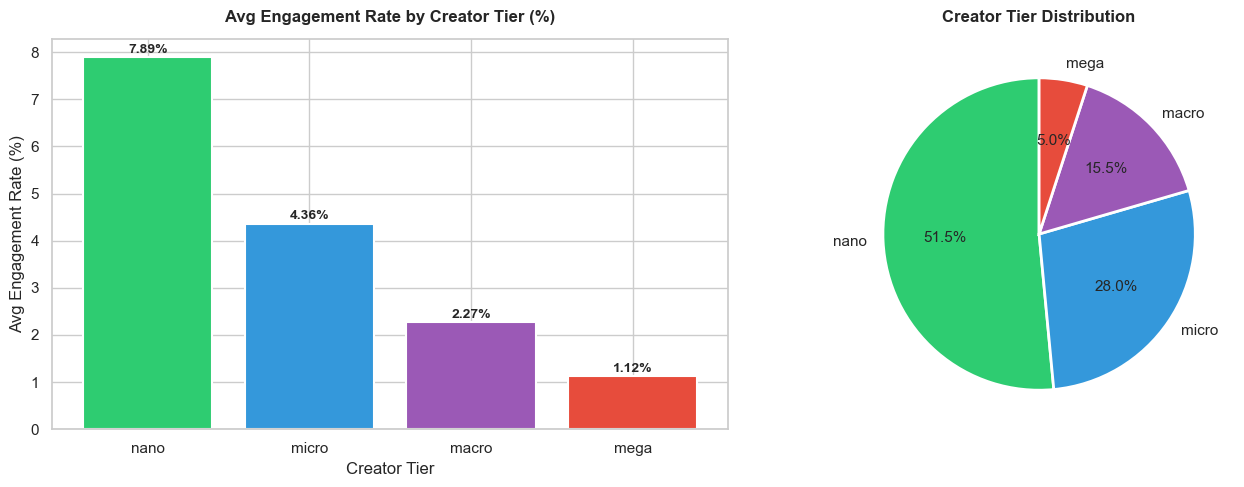

Chart 1 saved.


In [3]:
# ── Step 2: Creator tier analysis ────────────────────────────
# Core finding: engagement rate decreases as follower count grows.
# This is the inverse engagement-follower relationship.

TIER_ORDER  = ["nano", "micro", "macro", "mega"]
TIER_COLORS = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"]

tier_stats = (
    creators.groupby("tier")
    .agg(
        count               = ("creator_id",        "count"),
        avg_followers       = ("follower_count",     "mean"),
        avg_engagement_rate = ("avg_engagement_rate","mean"),
        avg_cost_inr        = ("estimated_cost_inr", "mean"),
    )
    .reindex(TIER_ORDER)
    .round(2)
)

print("=" * 55)
print("TIER STATS — engagement decreases as tier grows")
print("=" * 55)
print(tier_stats.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar: average engagement rate by tier
avg_er = [tier_stats.loc[t, "avg_engagement_rate"] for t in TIER_ORDER]
bars   = axes[0].bar(TIER_ORDER, avg_er, color=TIER_COLORS,
                      edgecolor="white", linewidth=1.5)
axes[0].set_title("Avg Engagement Rate by Creator Tier (%)",
                   fontweight="bold", pad=12)
axes[0].set_xlabel("Creator Tier")
axes[0].set_ylabel("Avg Engagement Rate (%)")
for bar, val in zip(bars, avg_er):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.2f}%",
        ha="center", fontweight="bold", fontsize=10,
    )

# pie: tier distribution
counts = creators["tier"].value_counts().reindex(TIER_ORDER)
axes[1].pie(
    counts.values,
    labels=TIER_ORDER,
    colors=TIER_COLORS,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Creator Tier Distribution", fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart_01_tier_analysis.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved.")

ENGAGEMENT vs CONVERSION RATE by tier
High engagement does NOT guarantee high sales.
       avg_engagement_rate  avg_cvr  total_posts
tier                                            
nano                 7.867    0.024          598
micro                4.449    2.438          297
macro                2.337    1.891          165
mega                 1.096    1.651           53



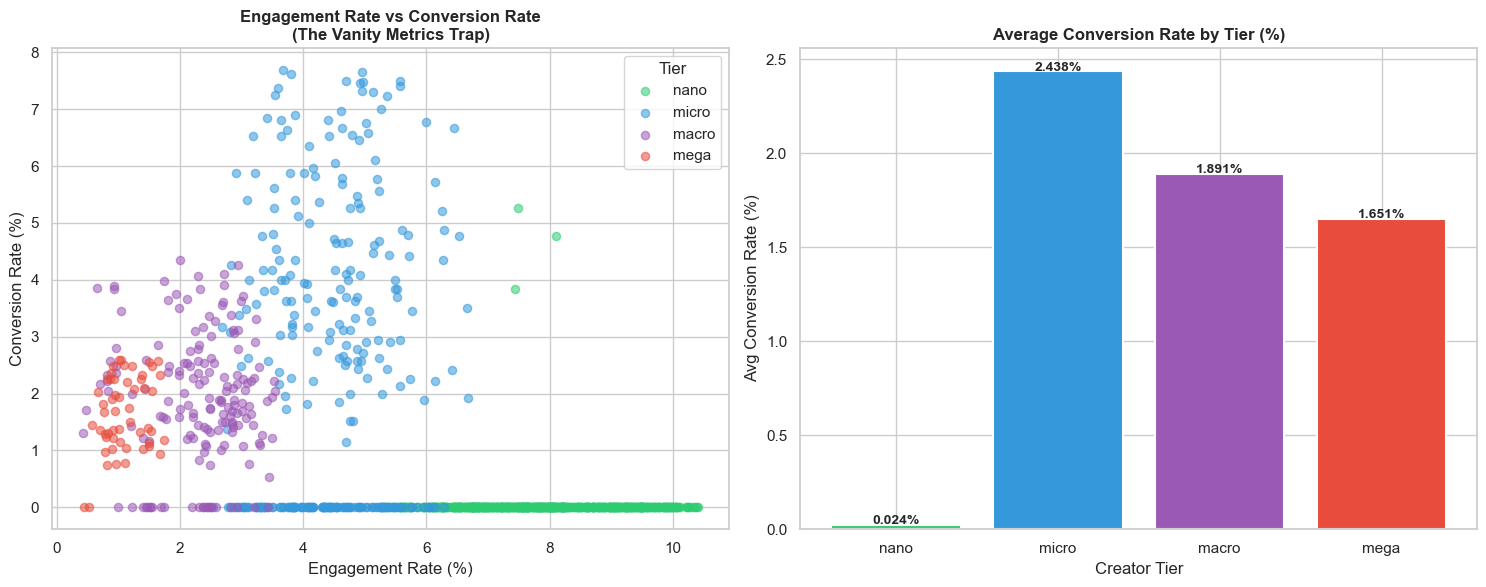

Chart 2 saved.


In [4]:
# ── Step 3: The vanity metrics trap ──────────────────────────
# Key question: does high engagement actually mean high sales?
# Expected finding: NO — this is the core insight of VibeSignal AI.

# compute post-level engagement rate
posts["engagement_rate"] = (
    (posts["likes"] + posts["comments"] +
     posts["shares"] + posts.get("saves", 0))
    / posts["reach"].replace(0, np.nan)
) * 100

# compute conversion rate per post
conv_counts  = conversions.groupby("post_id").size().reset_index(name="num_conv")
posts_merged = posts.merge(conv_counts, on="post_id", how="left")
posts_merged["num_conv"] = posts_merged["num_conv"].fillna(0)
posts_merged["cvr"] = (
    posts_merged["num_conv"]
    / posts_merged["clicks"].replace(0, np.nan)
) * 100

# merge creator tier
posts_full = posts_merged.merge(
    creators[["creator_id", "tier", "niche", "platform",
               "authenticity_risk_level"]],
    on="creator_id", how="left",
)

summary = (
    posts_full.groupby("tier")
    .agg(
        avg_engagement_rate = ("engagement_rate", "mean"),
        avg_cvr             = ("cvr",             "mean"),
        total_posts         = ("post_id",          "count"),
    )
    .reindex(TIER_ORDER)
    .round(3)
)

print("=" * 55)
print("ENGAGEMENT vs CONVERSION RATE by tier")
print("High engagement does NOT guarantee high sales.")
print("=" * 55)
print(summary.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# scatter: engagement rate vs conversion rate
colors_map = dict(zip(TIER_ORDER, TIER_COLORS))
for tier in TIER_ORDER:
    sub = posts_full[posts_full["tier"] == tier]
    axes[0].scatter(
        sub["engagement_rate"], sub["cvr"],
        label=tier, color=colors_map[tier], alpha=0.55, s=35,
    )
axes[0].set_title(
    "Engagement Rate vs Conversion Rate\n(The Vanity Metrics Trap)",
    fontweight="bold",
)
axes[0].set_xlabel("Engagement Rate (%)")
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].legend(title="Tier")

# bar: avg CVR by tier
cvr_vals = [summary.loc[t, "avg_cvr"] for t in TIER_ORDER]
b2 = axes[1].bar(TIER_ORDER, cvr_vals, color=TIER_COLORS,
                  edgecolor="white", linewidth=1.5)
axes[1].set_title("Average Conversion Rate by Tier (%)", fontweight="bold")
axes[1].set_xlabel("Creator Tier")
axes[1].set_ylabel("Avg Conversion Rate (%)")
for bar, val in zip(b2, cvr_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{val:.3f}%",
        ha="center", fontweight="bold", fontsize=10,
    )

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart_02_vanity_metrics_trap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved.")

PLATFORM PERFORMANCE
           avg_engagement_rate   avg_reach  avg_clicks  total_posts
platform                                                           
twitter                  5.389   41100.169      49.810          426
instagram                5.271  103470.949      86.933          371
youtube                  5.119  106669.633      93.288          316

CONTENT FORMAT PERFORMANCE
                avg_engagement_rate  avg_clicks  total_posts
content_format                                              
text                          5.483      58.083          121
carousel                      5.383      84.526           78
reel                          5.367      85.670          100
story                         5.327      64.326           95
video                         5.272      74.994          311
short                         5.218      89.084          166
image                         5.110      68.347          242



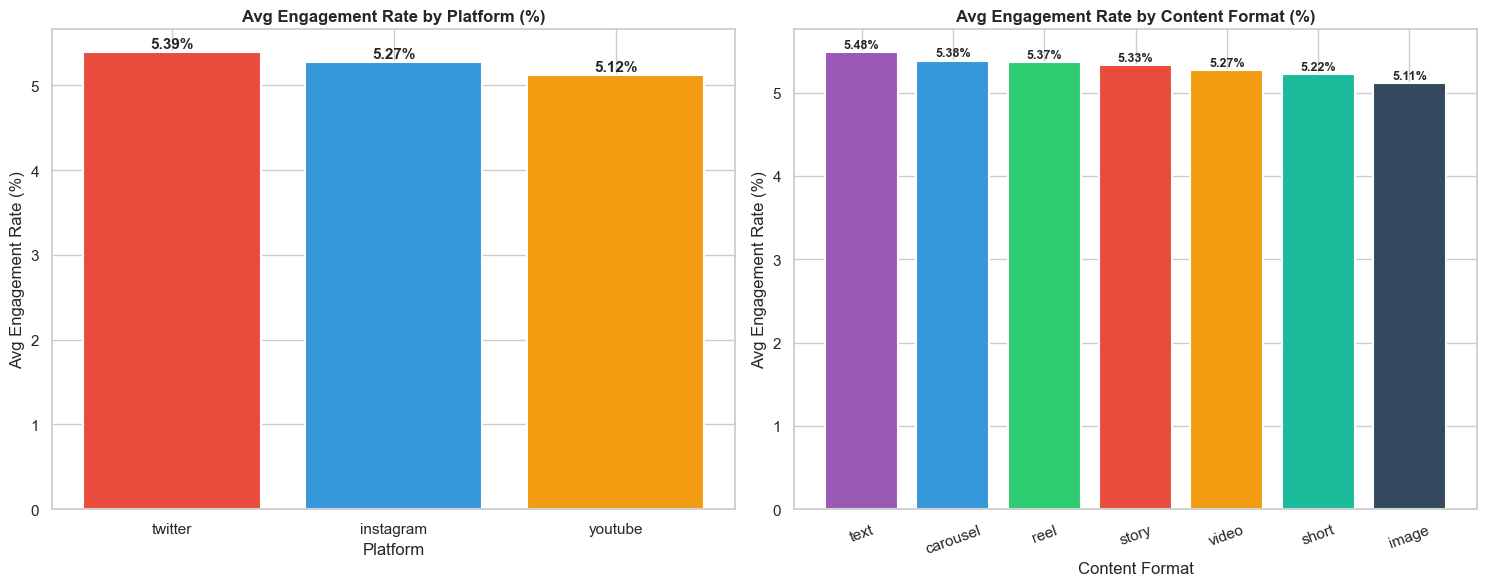

Chart 3 saved.


In [5]:
# ── Step 4: Platform and content format performance ──────────
# fully self-contained — no dependency on earlier cells

import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR   = r"C:\Users\vinni\vibesignal-ai\data"
CHARTS_DIR = r"C:\Users\vinni\vibesignal-ai\notebooks"

posts_raw   = pd.read_csv(os.path.join(DATA_DIR, "posts.csv"))
creators_raw = pd.read_csv(os.path.join(DATA_DIR, "creators.csv"))

# compute engagement rate
posts_raw["engagement_rate"] = (
    (posts_raw["likes"] + posts_raw["comments"] + posts_raw["shares"])
    / posts_raw["reach"].replace(0, float("nan"))
) * 100

# platform stats — posts already has platform column, no merge needed
platform_stats = (
    posts_raw.groupby("platform")
    .agg(
        avg_engagement_rate = ("engagement_rate", "mean"),
        avg_reach           = ("reach",           "mean"),
        avg_clicks          = ("clicks",          "mean"),
        total_posts         = ("post_id",          "count"),
    )
    .round(3)
    .sort_values("avg_engagement_rate", ascending=False)
)

# content format stats
format_stats = (
    posts_raw.groupby("content_format")
    .agg(
        avg_engagement_rate = ("engagement_rate", "mean"),
        avg_clicks          = ("clicks",          "mean"),
        total_posts         = ("post_id",          "count"),
    )
    .round(3)
    .sort_values("avg_engagement_rate", ascending=False)
)

print("=" * 55)
print("PLATFORM PERFORMANCE")
print("=" * 55)
print(platform_stats.to_string())
print()
print("=" * 55)
print("CONTENT FORMAT PERFORMANCE")
print("=" * 55)
print(format_stats.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# platform bar
plat_colors = ["#e74c3c", "#3498db", "#f39c12",
               "#2ecc71", "#9b59b6"]
p_er = platform_stats["avg_engagement_rate"]
b3   = axes[0].bar(
    p_er.index, p_er.values,
    color=plat_colors[:len(p_er)],
    edgecolor="white", linewidth=1.5,
)
axes[0].set_title("Avg Engagement Rate by Platform (%)",
                   fontweight="bold")
axes[0].set_xlabel("Platform")
axes[0].set_ylabel("Avg Engagement Rate (%)")
for bar, val in zip(b3, p_er.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.2f}%",
        ha="center", fontweight="bold",
    )

# content format bar
fmt_colors = ["#9b59b6", "#3498db", "#2ecc71",
              "#e74c3c", "#f39c12", "#1abc9c", "#34495e"]
f_er = format_stats["avg_engagement_rate"]
b4   = axes[1].bar(
    f_er.index, f_er.values,
    color=fmt_colors[:len(f_er)],
    edgecolor="white", linewidth=1.5,
)
axes[1].set_title("Avg Engagement Rate by Content Format (%)",
                   fontweight="bold")
axes[1].set_xlabel("Content Format")
axes[1].set_ylabel("Avg Engagement Rate (%)")
axes[1].tick_params(axis="x", rotation=20)
for bar, val in zip(b4, f_er.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.2f}%",
        ha="center", fontweight="bold", fontsize=9,
    )

plt.tight_layout()
plt.savefig(
    os.path.join(CHARTS_DIR, "chart_03_platform_format.png"),
    dpi=150, bbox_inches="tight",
)
plt.show()
print("Chart 3 saved.")

ROI ANALYSIS BY CREATOR TIER (INR)
       avg_fee_inr  avg_revenue_inr  avg_roi_pct  total_partnerships
tier                                                                
nano       4895.52          9919.37       103.82               234.0
micro     22587.93         49229.10       120.34                97.0
macro    123113.28        255532.72       118.84                30.0
mega           NaN              NaN          NaN                 NaN

TOP 10 CREATORS BY ROI (%)
                 avg_roi  total_revenue_inr  total_fee_inr
name                                                      
Bhavya Mandal     391.86           15567.65        3165.06
Tanvi Mutti       388.59          359967.60       73674.47
Bhavika Keer      371.68           11753.78        2491.89
Garima Bala       369.07          137466.86       29306.51
Ekantika Korpal   363.60           87861.73       18952.09
Rachita Pathak    357.70           13375.44        2922.29
Sarthak Kakar     327.50          578731.39      13

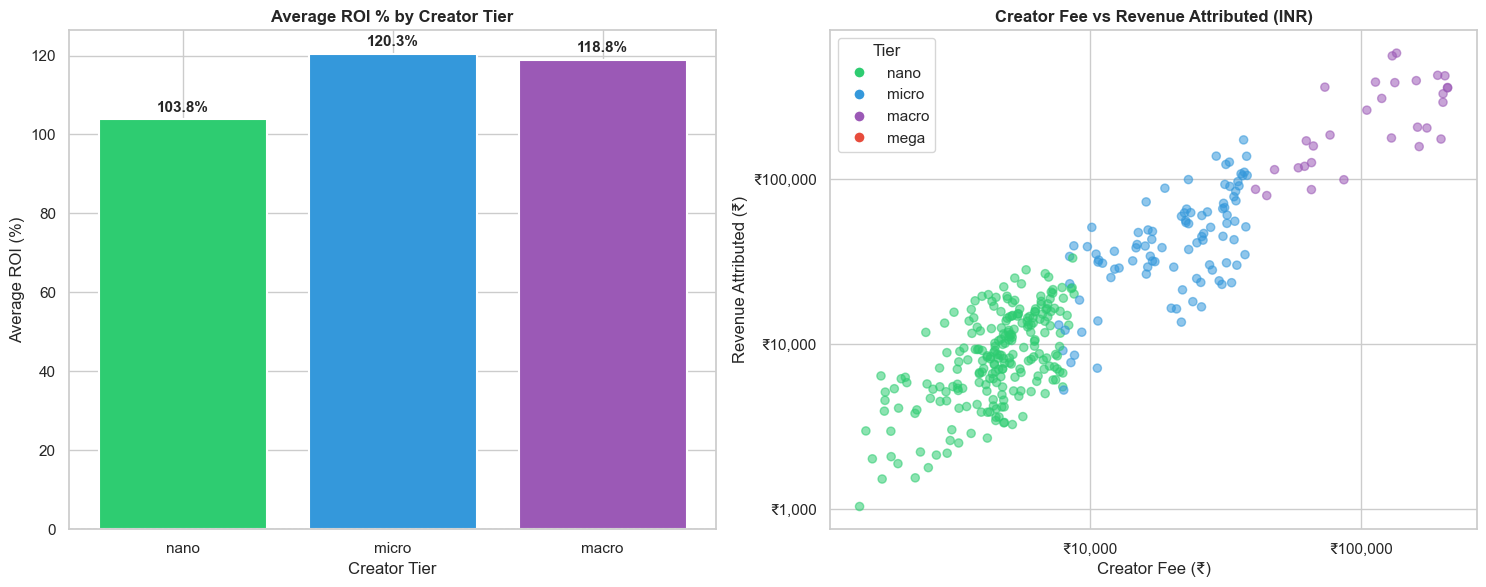

Chart 4 saved.


In [6]:
# ── Step 5: ROI analysis in INR ──────────────────────────────

cc = campaign_creators.merge(
    creators[["creator_id", "tier", "niche", "platform"]],
    on="creator_id", how="left",
)

cc["roi_pct"] = (
    (cc["revenue_attributed_inr"] - cc["creator_fee_inr"])
    / cc["creator_fee_inr"].replace(0, np.nan)
) * 100

roi_by_tier = (
    cc.groupby("tier")
    .agg(
        avg_fee_inr       = ("creator_fee_inr",        "mean"),
        avg_revenue_inr   = ("revenue_attributed_inr", "mean"),
        avg_roi_pct       = ("roi_pct",                "mean"),
        total_partnerships= ("cc_id",                  "count"),
    )
    .reindex(TIER_ORDER)
    .round(2)
)

print("=" * 55)
print("ROI ANALYSIS BY CREATOR TIER (INR)")
print("=" * 55)
print(roi_by_tier.to_string())
print()

# top 10 creators by ROI
creator_roi = (
    cc.merge(creators[["creator_id", "name"]], on="creator_id", how="left")
    .groupby("name")
    .agg(
        avg_roi          = ("roi_pct",                "mean"),
        total_revenue_inr= ("revenue_attributed_inr", "sum"),
        total_fee_inr    = ("creator_fee_inr",        "sum"),
    )
    .sort_values("avg_roi", ascending=False)
    .head(10)
    .round(2)
)

print("=" * 55)
print("TOP 10 CREATORS BY ROI (%)")
print("=" * 55)
print(creator_roi.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# bar: avg ROI by tier
roi_vals = [roi_by_tier.loc[t, "avg_roi_pct"] for t in TIER_ORDER]
b5 = axes[0].bar(TIER_ORDER, roi_vals, color=TIER_COLORS,
                  edgecolor="white", linewidth=1.5)
axes[0].set_title("Average ROI % by Creator Tier", fontweight="bold")
axes[0].set_xlabel("Creator Tier")
axes[0].set_ylabel("Average ROI (%)")
axes[0].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(b5, roi_vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{val:.1f}%",
        ha="center", fontweight="bold",
    )

# scatter: fee vs revenue (log scale for INR range)
axes[1].scatter(
    cc["creator_fee_inr"],
    cc["revenue_attributed_inr"],
    c=cc["tier"].map(colors_map),
    alpha=0.55, s=35,
)
axes[1].set_title("Creator Fee vs Revenue Attributed (INR)",
                   fontweight="bold")
axes[1].set_xlabel("Creator Fee (₹)")
axes[1].set_ylabel("Revenue Attributed (₹)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}")
)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}")
)

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=c, markersize=8, label=t)
    for t, c in zip(TIER_ORDER, TIER_COLORS)
]
axes[1].legend(handles=legend_els, title="Tier")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart_04_roi_analysis.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved.")

REVENUE SUMMARY (INR)
Total synthetic revenue:  ₹3,032,868.38
Total conversions:        1,972
Average order value:      ₹1,537.97

Revenue by device type:
                    sum     mean  count
device_type                            
desktop       581637.01  1602.31    363
mobile       2208583.40  1511.69   1461
tablet        242647.97  1639.51    148

Revenue by city (top 5):
location
Pune       ₹358,295
Kolkata    ₹342,335
Surat      ₹336,051
Jaipur     ₹327,303
Chennai    ₹297,729
Name: order_value_inr, dtype: object



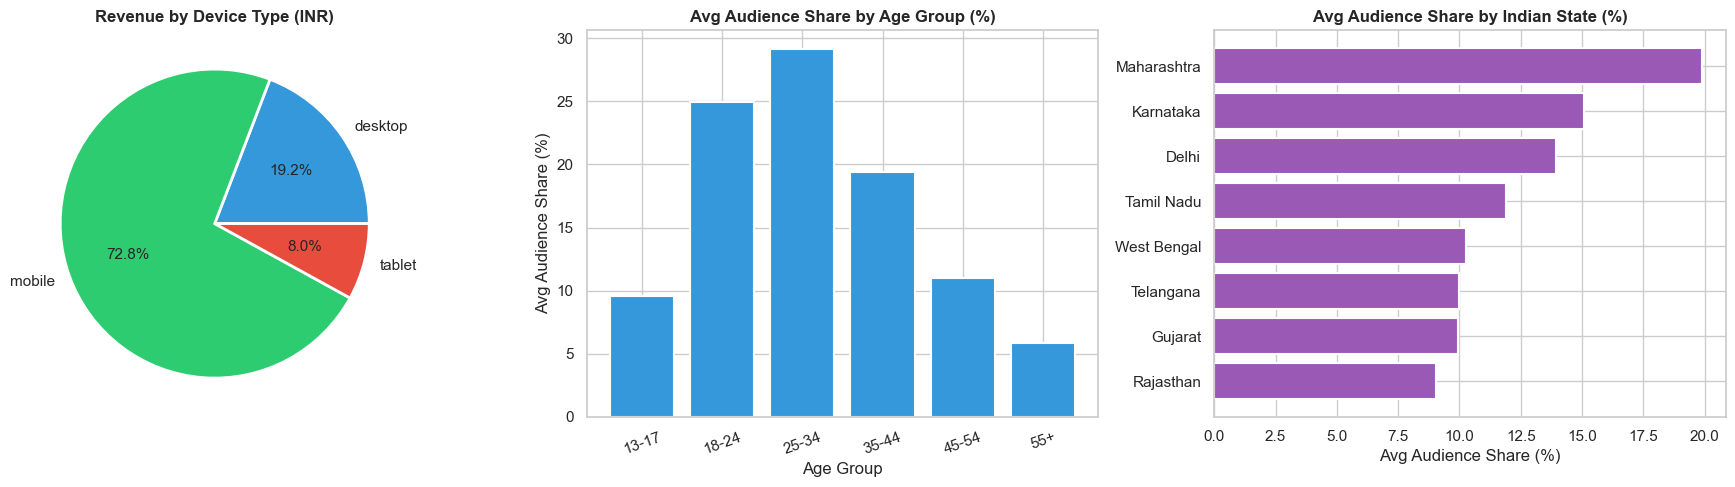

Chart 5 saved.


In [7]:
# ── Step 6: Revenue and audience summary — India context ──────

total_revenue  = conversions["order_value_inr"].sum()
avg_order      = conversions["order_value_inr"].mean()
total_orders   = len(conversions)

print("=" * 55)
print("REVENUE SUMMARY (INR)")
print("=" * 55)
print(f"Total synthetic revenue:  ₹{total_revenue:,.2f}")
print(f"Total conversions:        {total_orders:,}")
print(f"Average order value:      ₹{avg_order:,.2f}")
print()

print("Revenue by device type:")
print(
    conversions.groupby("device_type")["order_value_inr"]
    .agg(["sum", "mean", "count"]).round(2)
)
print()

print("Revenue by city (top 5):")
print(
    conversions.groupby("location")["order_value_inr"]
    .sum().sort_values(ascending=False).head(5)
    .apply(lambda x: f"₹{x:,.0f}")
)
print()

# demographics breakdown from long-format table
age_demo    = demographics[demographics["demographic_type"] == "age_group"]
state_demo  = demographics[demographics["demographic_type"] == "state"]

avg_age_share = (
    age_demo.groupby("demographic_value")["percentage_share"]
    .mean()
    .reindex(["13-17","18-24","25-34","35-44","45-54","55+"])
)

avg_state_share = (
    state_demo.groupby("demographic_value")["percentage_share"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# device revenue pie
device_rev = conversions.groupby("device_type")["order_value_inr"].sum()
axes[0].pie(
    device_rev.values,
    labels=device_rev.index,
    autopct="%1.1f%%",
    colors=["#3498db", "#2ecc71", "#e74c3c"],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Revenue by Device Type (INR)", fontweight="bold")

# age group audience share bar
axes[1].bar(
    avg_age_share.index,
    avg_age_share.values,
    color="#3498db", edgecolor="white", linewidth=1.5,
)
axes[1].set_title("Avg Audience Share by Age Group (%)", fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Avg Audience Share (%)")
axes[1].tick_params(axis="x", rotation=20)

# Indian state audience share bar
axes[2].barh(
    avg_state_share.index,
    avg_state_share.values,
    color="#9b59b6", edgecolor="white", linewidth=1.5,
)
axes[2].set_title("Avg Audience Share by Indian State (%)", fontweight="bold")
axes[2].set_xlabel("Avg Audience Share (%)")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart_05_india_revenue_summary.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved.")

In [10]:
# ── Step 7: Key insights summary ─────────────────────────────
# fully self-contained — loads and computes everything from scratch

import os
import numpy as np
import pandas as pd

DATA_DIR = r"C:\Users\vinni\vibesignal-ai\data"

creators_raw          = pd.read_csv(os.path.join(DATA_DIR, "creators.csv"))
posts_raw             = pd.read_csv(os.path.join(DATA_DIR, "posts.csv"))
conversions_raw       = pd.read_csv(os.path.join(DATA_DIR, "conversions.csv"))
campaign_creators_raw = pd.read_csv(os.path.join(DATA_DIR, "campaign_creators.csv"))

TIER_ORDER = ["nano", "micro", "macro", "mega"]

# engagement rate per post
posts_raw["engagement_rate"] = (
    (posts_raw["likes"] + posts_raw["comments"] + posts_raw["shares"])
    / posts_raw["reach"].replace(0, np.nan)
) * 100

# conversion rate per post
conv_counts = (
    conversions_raw.groupby("post_id")
    .size()
    .reset_index(name="num_conv")
)
posts_m = posts_raw.merge(conv_counts, on="post_id", how="left")
posts_m["num_conv"] = posts_m["num_conv"].fillna(0)
posts_m["cvr"] = (
    posts_m["num_conv"]
    / posts_m["clicks"].replace(0, np.nan)
) * 100

# merge tier from creators
posts_m = posts_m.merge(
    creators_raw[["creator_id", "tier"]],
    on="creator_id", how="left",
)

# tier summary
summary = (
    posts_m.groupby("tier")
    .agg(
        avg_engagement_rate = ("engagement_rate", "mean"),
        avg_cvr             = ("cvr",             "mean"),
    )
    .reindex(TIER_ORDER)
    .round(3)
)

# platform stats — platform column already on posts
platform_stats = (
    posts_raw.groupby("platform")["engagement_rate"]
    .mean()
)

# format stats
format_stats = (
    posts_raw.groupby("content_format")["engagement_rate"]
    .mean()
)

# revenue
total_revenue = conversions_raw["order_value_inr"].sum()
avg_order     = conversions_raw["order_value_inr"].mean()
top_city      = (
    conversions_raw.groupby("location")["order_value_inr"]
    .sum().idxmax()
)
mobile_pct = conversions_raw["device_type"].eq("mobile").mean() * 100

# pull insight values
nano_er       = creators_raw[creators_raw["tier"] == "nano"]["avg_engagement_rate"].mean()
mega_er       = creators_raw[creators_raw["tier"] == "mega"]["avg_engagement_rate"].mean()
nano_cvr      = summary.loc["nano", "avg_cvr"]
mega_cvr      = summary.loc["mega", "avg_cvr"]
best_platform = platform_stats.idxmax()
best_er_val   = platform_stats.max()
best_format   = format_stats.idxmax()
best_fmt_val  = format_stats.max()

print("=" * 60)
print("VIBESIGNAL AI — EDA KEY INSIGHTS")
print("=" * 60)
print()
print("INSIGHT 1 — Inverse Engagement Rule:")
print(f"  Nano creators engage at  {nano_er:.2f}%")
print(f"  Mega creators engage at  {mega_er:.2f}%")
print(f"  Nano creators are {nano_er/mega_er:.0f}x better at engagement")
print()
print("INSIGHT 2 — The Vanity Metrics Trap:")
print(f"  Nano CVR:  {nano_cvr:.3f}%")
print(f"  Mega CVR:  {mega_cvr:.3f}%")
if nano_cvr > 0:
    print(f"  Despite lower engagement, mega creators")
    print(f"  convert {mega_cvr/nano_cvr:.0f}x better than nano creators")
print()
print("INSIGHT 3 — Best Platform for Engagement:")
print(f"  {best_platform.title()} leads at {best_er_val:.2f}% avg engagement")
print()
print("INSIGHT 4 — Best Content Format:")
print(f"  {best_format.title()} performs best at {best_fmt_val:.2f}%")
print()
print("INSIGHT 5 — Indian Market Revenue:")
print(f"  Total synthetic revenue: ₹{total_revenue:,.2f}")
print(f"  Avg order value:         ₹{avg_order:,.2f}")
print(f"  Top city by revenue:     {top_city}")
print(f"  Mobile drives {mobile_pct:.0f}% of all conversions")
print()
print("=" * 60)
print("EDA complete")
print("=" * 60)

VIBESIGNAL AI — EDA KEY INSIGHTS

INSIGHT 1 — Inverse Engagement Rule:
  Nano creators engage at  7.89%
  Mega creators engage at  1.12%
  Nano creators are 7x better at engagement

INSIGHT 2 — The Vanity Metrics Trap:
  Nano CVR:  0.024%
  Mega CVR:  1.651%
  Despite lower engagement, mega creators
  convert 69x better than nano creators

INSIGHT 3 — Best Platform for Engagement:
  Twitter leads at 5.39% avg engagement

INSIGHT 4 — Best Content Format:
  Text performs best at 5.48%

INSIGHT 5 — Indian Market Revenue:
  Total synthetic revenue: ₹3,032,868.38
  Avg order value:         ₹1,537.97
  Top city by revenue:     Pune
  Mobile drives 74% of all conversions

EDA complete
